
▶ Running alignment: 1-day
Valid days : 840
Mean corr  : 0.0487
Std corr   : 0.2184
t-stat    : 6.46
p-value   : 1.8268e-10

▶ Running alignment: 5-day
Valid days : 840
Mean corr  : 0.0581
Std corr   : 0.2360
t-stat    : 7.13
p-value   : 2.2232e-12

▶ Running alignment: 20-day
Valid days : 840
Mean corr  : 0.0582
Std corr   : 0.2340
t-stat    : 7.21
p-value   : 1.2653e-12

▶ Running alignment: 60-day
Valid days : 800
Mean corr  : 0.0539
Std corr   : 0.2367
t-stat    : 6.44
p-value   : 2.0597e-10

📊 FINAL SUMMARY
Horizon     Mean      Std   t-stat      p-value  Days
  1-day 0.048670 0.218388 6.455191 1.826823e-10   840
  5-day 0.058073 0.236045 7.126233 2.223219e-12   840
 20-day 0.058229 0.233989 7.208156 1.265300e-12   840
 60-day 0.053936 0.236734 6.440106 2.059714e-10   800

💾 Saved: alignment_summary_all_horizons.csv

🖼️  GENERATING FIGURES


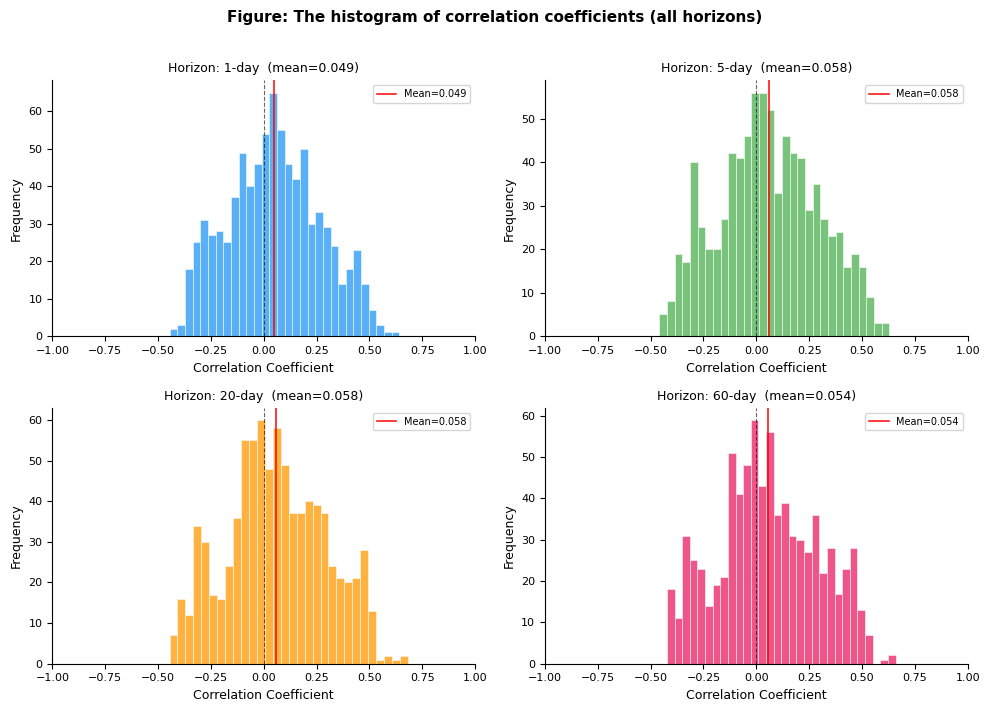

💾 Saved: histogram_corr_all.png


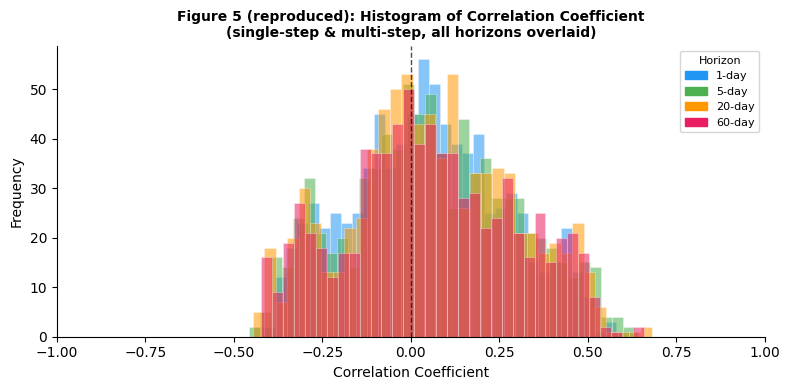

💾 Saved: histogram_corr_overlaid.png


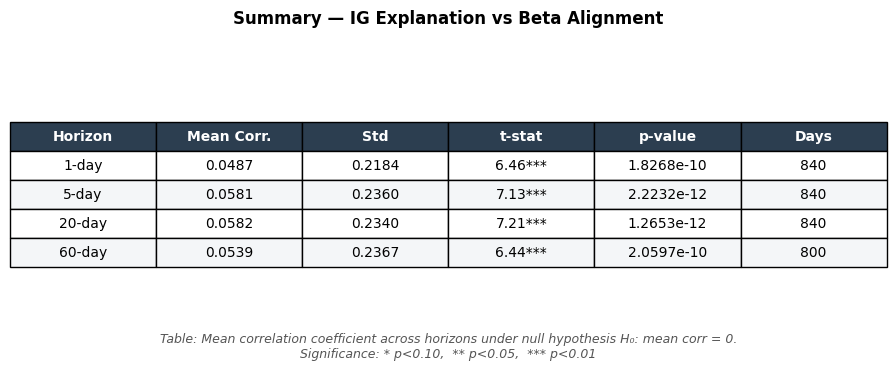

💾 Saved: summary_table.png

✅ All figures saved successfully.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, ttest_1samp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ======================================================
# CONFIG
# ======================================================
IG_PATH = "/content/ig_explanation_5_L110m_N10_L21m_K1 (2).csv"

BETA_PATHS = {
    "1-day":  "/content/beta_single_step.csv",
    "5-day":  "/content/beta_multi_step_W5.csv",
    "20-day": "/content/beta_multi_step_W20.csv",
    "60-day": "/content/beta_multi_step_W60.csv",
}

START_DATE = "2022-02-07"
END_DATE   = "2025-06-18"

DROP_IG_COLS = ["cash", "prices", "shares", "news_embedding"]

FEATURE_MAP = {
    "ind_rsi_30": "rsi_30",
    "ind_macd": "macd",
    "ind_boll_ub": "boll_ub",
    "ind_boll_lb": "boll_lb",
    "ind_cci_30": "cci_30",
    "ind_dx_30": "dx_30",
    "ind_close_30_sma": "close_30_sma",
    "ind_close_60_sma": "close_60_sma",
}

# Color palette for horizons (similar to paper style)
HORIZON_COLORS = {
    "1-day":  "#2196F3",   # blue
    "5-day":  "#4CAF50",   # green
    "20-day": "#FF9800",   # orange
    "60-day": "#E91E63",   # pink/red
}

# ======================================================
# CORE FUNCTION
# ======================================================
def run_alignment(ig_path, beta_path, label):
    print(f"\n{'='*70}")
    print(f"▶ Running alignment: {label}")
    print(f"{'='*70}")

    ig_df = pd.read_csv(ig_path)
    beta_df = pd.read_csv(beta_path)

    # Fix date column
    if ig_df.columns[0] != "date":
        ig_df.rename(columns={ig_df.columns[0]: "date"}, inplace=True)
    if beta_df.columns[0] != "date":
        beta_df.rename(columns={beta_df.columns[0]: "date"}, inplace=True)

    ig_df["date"] = pd.to_datetime(ig_df["date"], format="mixed")
    beta_df["date"] = pd.to_datetime(beta_df["date"], format="mixed")

    # Filter date
    ig_df = ig_df[(ig_df["date"] >= START_DATE) & (ig_df["date"] <= END_DATE)]
    beta_df = beta_df[(beta_df["date"] >= START_DATE) & (beta_df["date"] <= END_DATE)]

    ig_df = ig_df.sort_values("date")
    beta_df = beta_df.sort_values("date")

    # Drop unwanted IG cols
    ig_df = ig_df.drop(columns=[c for c in DROP_IG_COLS if c in ig_df.columns], errors="ignore")

    # Keep only mapped features
    ig_cols = ["date"] + [c for c in FEATURE_MAP.keys() if c in ig_df.columns]
    beta_cols = ["date"] + [c for c in FEATURE_MAP.values() if c in beta_df.columns]

    ig_df = ig_df[ig_cols]
    beta_df = beta_df[beta_cols]

    # Merge
    df = ig_df.merge(beta_df, on="date", how="inner")

    daily_corrs = []
    used_dates = []

    for _, row in df.iterrows():
        M_t, beta_t = [], []

        for ig_c, beta_c in FEATURE_MAP.items():
            if ig_c in row.index and beta_c in row.index:
                M_t.append(row[ig_c])
                beta_t.append(row[beta_c])

        M_t = np.array(M_t)
        beta_t = np.array(beta_t)

        if (
            len(M_t) == 0
            or np.any(np.isnan(M_t))
            or np.any(np.isnan(beta_t))
            or np.std(M_t) == 0
            or np.std(beta_t) == 0
        ):
            continue

        corr, _ = pearsonr(M_t, beta_t)
        daily_corrs.append(corr)
        used_dates.append(row["date"])

    daily_corrs = np.array(daily_corrs)

    # =======================
    # STATISTICS + TEST
    # =======================
    mean_corr = np.mean(daily_corrs)
    std_corr  = np.std(daily_corrs)

    t_stat, p_val = ttest_1samp(daily_corrs, 0)

    print(f"Valid days : {len(daily_corrs)}")
    print(f"Mean corr  : {mean_corr:.4f}")
    print(f"Std corr   : {std_corr:.4f}")
    print(f"t-stat    : {t_stat:.2f}")
    print(f"p-value   : {p_val:.4e}")

    # Save daily
    out_daily = pd.DataFrame({
        "date": used_dates,
        f"corr_{label}": daily_corrs
    }).sort_values("date")

    out_daily.to_csv(f"daily_corr_{label}.csv", index=False)

    return {
        "Horizon": label,
        "Mean": mean_corr,
        "Std": std_corr,
        "t-stat": t_stat,
        "p-value": p_val,
        "Days": len(daily_corrs),
        "_daily_corrs": daily_corrs  # kept for plotting, removed before saving summary
    }


# ======================================================
# PLOT FUNCTIONS
# ======================================================

def plot_histograms(all_results, step_type="single"):
    """
    Plot histogram of correlation coefficients for each horizon,
    arranged in a 2x2 grid (similar to Figure 5 / Figure 6 in the paper).

    step_type: "single" uses 1-day horizon only (shown as single-step),
               "multi" uses 5/20/60-day horizons (multi-step).
    For this implementation we show ALL horizons, each in its own subplot.
    """
    horizons = [r["Horizon"] for r in all_results]
    n = len(horizons)

    # Determine grid layout
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    title_map = {
        "single": "Figure: The histogram of correlation coefficient (single-step)",
        "multi":  "Figure: The histogram of correlation coefficients (multi-step)",
        "all":    "Figure: The histogram of correlation coefficients (all horizons)",
    }

    for i, res in enumerate(all_results):
        ax = axes[i]
        label = res["Horizon"]
        daily_corrs = res["_daily_corrs"]
        color = HORIZON_COLORS.get(label, "#607D8B")

        ax.hist(daily_corrs, bins=30, color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
        ax.set_xlim(-1, 1)
        ax.set_xlabel("Correlation Coefficient", fontsize=9)
        ax.set_ylabel("Frequency", fontsize=9)
        ax.set_title(f"Horizon: {label}  (mean={res['Mean']:.3f})", fontsize=9)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
        ax.axvline(res["Mean"], color="red", linewidth=1.2, linestyle="-", alpha=0.9,
                   label=f"Mean={res['Mean']:.3f}")
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title_map.get(step_type, "Correlation Coefficient Histograms"),
                 fontsize=11, fontweight="bold", y=1.01)
    plt.tight_layout()
    fname = f"histogram_corr_{step_type}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"💾 Saved: {fname}")


def plot_single_step_histogram(all_results):
    """
    Replicates Figure 5 style: single-step (1-day) correlation histograms.
    Shows one large histogram with all horizons overlaid for comparison.
    """
    fig, ax = plt.subplots(figsize=(8, 4))

    patches = []
    for res in all_results:
        label = res["Horizon"]
        daily_corrs = res["_daily_corrs"]
        color = HORIZON_COLORS.get(label, "#607D8B")
        ax.hist(daily_corrs, bins=35, color=color, alpha=0.55, edgecolor="white",
                linewidth=0.4, label=label)
        patches.append(mpatches.Patch(color=color, label=label))

    ax.set_xlim(-1, 1)
    ax.set_xlabel("Correlation Coefficient", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.axvline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.legend(handles=patches, fontsize=8, title="Horizon", title_fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title("Figure 5 (reproduced): Histogram of Correlation Coefficient\n(single-step & multi-step, all horizons overlaid)",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.savefig("histogram_corr_overlaid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: histogram_corr_overlaid.png")


def plot_summary_table(summary_df):
    """
    Renders a clean publication-style table image (similar to Table 2 / results table in paper).
    """
    fig, ax = plt.subplots(figsize=(9, len(summary_df) * 0.55 + 1.5))
    ax.axis("off")

    # Prepare display data
    display_cols = ["Horizon", "Mean Corr.", "Std", "t-stat", "p-value", "Days"]
    table_data = []
    for _, row in summary_df.iterrows():
        # Format p-value with significance stars
        p = row["p-value"]
        stars = ""
        if p < 0.01:
            stars = "***"
        elif p < 0.05:
            stars = "**"
        elif p < 0.10:
            stars = "*"

        table_data.append([
            row["Horizon"],
            f"{row['Mean']:.4f}",
            f"{row['Std']:.4f}",
            f"{row['t-stat']:.2f}{stars}",
            f"{p:.4e}",
            f"{int(row['Days'])}",
        ])

    tbl = ax.table(
        cellText=table_data,
        colLabels=display_cols,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.6)

    # Style header
    for j in range(len(display_cols)):
        tbl[(0, j)].set_facecolor("#2c3e50")
        tbl[(0, j)].set_text_props(color="white", fontweight="bold")

    # Alternating row shading
    for i in range(1, len(table_data) + 1):
        bg = "#f4f6f8" if i % 2 == 0 else "white"
        for j in range(len(display_cols)):
            tbl[(i, j)].set_facecolor(bg)

    caption = (
        "Table: Mean correlation coefficient across horizons under null hypothesis H₀: mean corr = 0.\n"
        "Significance: * p<0.10,  ** p<0.05,  *** p<0.01"
    )
    fig.text(0.5, 0.02, caption, ha="center", fontsize=9, style="italic", color="#555555")
    ax.set_title("Summary — IG Explanation vs Beta Alignment",
                 fontsize=12, fontweight="bold", pad=12)

    plt.tight_layout()
    plt.savefig("summary_table.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: summary_table.png")


# ======================================================
# RUN ALL HORIZONS
# ======================================================
summary_rows = []

for label, beta_path in BETA_PATHS.items():
    res = run_alignment(IG_PATH, beta_path, label)
    summary_rows.append(res)

# Build summary (exclude raw corr arrays)
summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "_daily_corrs"}
    for r in summary_rows
])
summary_df.to_csv("alignment_summary_all_horizons.csv", index=False)

print("\n" + "="*70)
print("📊 FINAL SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("\n💾 Saved: alignment_summary_all_horizons.csv")

# ======================================================
# GENERATE FIGURES
# ======================================================
print("\n" + "="*70)
print("🖼️  GENERATING FIGURES")
print("="*70)

# Figure A: Subplot histograms (one per horizon) — style of Figure 5/6
plot_histograms(summary_rows, step_type="all")

# Figure B: Overlaid histogram (all horizons on same axes) — alternative view
plot_single_step_histogram(summary_rows)

# Figure C: Summary table image
plot_summary_table(summary_df)

print("\n✅ All figures saved successfully.")

In [ ]:
import pandas as pd
import numpy as np

# ===================== INPUT DATA =====================

df = pd.read_excel("/content/test2025_risk.xlsx", parse_dates=["date"])

# Sort đúng thứ tự thời gian
df = df.sort_values(["tic", "date"]).reset_index(drop=True)

# ===================== CONSTANT =====================
TRADING_DAYS = 252

# ===================== METRIC FUNCTIONS =====================

def annualized_return(log_returns):
    """
    Lợi nhuận năm (lãi kép) từ log-return ngày
    """
    log_returns = log_returns.dropna()
    return np.exp(log_returns.mean() * TRADING_DAYS) - 1


def annualized_variance(log_returns):
    """
    Phương sai năm
    """
    log_returns = log_returns.dropna()
    return log_returns.var() * TRADING_DAYS


def sharpe_ratio(log_returns, rf=0.0):
    log_returns = log_returns.dropna()
    std = log_returns.std()
    if std == 0 or np.isnan(std):
        return np.nan
    return (log_returns.mean() - rf) / std * np.sqrt(TRADING_DAYS)


def sortino_ratio(log_returns, rf=0.0):
    log_returns = log_returns.dropna()
    downside = log_returns[log_returns < 0]
    std_down = downside.std()
    if std_down == 0 or np.isnan(std_down):
        return np.nan
    return (log_returns.mean() - rf) / std_down * np.sqrt(TRADING_DAYS)


def max_drawdown(log_returns):
    log_returns = log_returns.dropna()
    cum = np.exp(log_returns.cumsum())
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    return drawdown.min()


def calmar_ratio(log_returns):
    log_returns = log_returns.dropna()
    mdd = abs(max_drawdown(log_returns))
    if mdd == 0 or np.isnan(mdd):
        return np.nan
    annual_ret = annualized_return(log_returns)
    return annual_ret / mdd


def cvar(log_returns, alpha):
    log_returns = log_returns.dropna()
    var = np.quantile(log_returns, alpha)
    return log_returns[log_returns <= var].mean()


# ===================== MAIN COMPUTATION =====================

def compute_stock_metrics(df):
    results = []

    for tic, g in df.groupby("tic"):
        r = g["log-return"]

        metrics = {
            "tic": tic,

            # ===== Annualized metrics =====
            "annual_return": annualized_return(r),
            "annual_variance": annualized_variance(r),

            # ===== Risk tail (daily, giữ nguyên để không bóp méo) =====
            "cvar_1pct": cvar(r, 0.01),
            "cvar_5pct": cvar(r, 0.05),
            "cvar_10pct": cvar(r, 0.10),

            # ===== Drawdown & ratios =====
            "max_drawdown": max_drawdown(r),
            "sharpe": sharpe_ratio(r),
            "sortino": sortino_ratio(r),
            "calmar": calmar_ratio(r),
        }

        results.append(metrics)

    return pd.DataFrame(results)


# ===================== OPTIONAL: CUT TEST PERIOD =====================
df = df[df["date"] >= "2023-04-04"]

# ===================== RUN =====================

metrics_df = compute_stock_metrics(df)

metrics_df = metrics_df.sort_values("annual_return", ascending=False)

print(metrics_df)


    tic  annual_return  annual_variance  cvar_1pct  cvar_5pct  cvar_10pct  \
1   BMP       0.689301         0.132328  -0.068658  -0.044241   -0.035669   
14  IMP       0.546506         0.103475  -0.068722  -0.042668   -0.031825   
4   CTD       0.536785         0.156721  -0.072225  -0.059057   -0.044752   
5   DBC       0.519377         0.164063  -0.072276  -0.061186   -0.046661   
26  VIX       0.474033         0.182530  -0.071615  -0.061570   -0.048714   
2   BSI       0.448153         0.181174  -0.071978  -0.063895   -0.048552   
7   FPT       0.367634         0.064988  -0.059761  -0.035964   -0.026967   
17  MBB       0.327953         0.051622  -0.055220  -0.031618   -0.023790   
22  REE       0.233659         0.064026  -0.057601  -0.033832   -0.026037   
10  HCM       0.224663         0.125225  -0.071889  -0.056637   -0.042015   
19  PDR       0.197442         0.172996  -0.072258  -0.059328   -0.047116   
23  SSI       0.179463         0.104972  -0.071535  -0.050824   -0.037281   

# Kiểm định Xu hướng


In [ ]:
!pip install statsmodels --upgrade

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# 0. PATHS & PARAMS
# =========================================================
VNM_PATH   = "vnm.csv"
STOCK_PATH = "/content/test2025_risk.xlsx"
ALLOC_PATH = "allocation_5_L110m_N10_L21m_K1_opent+1.csv"

TREND_WINDOWS  = [7, 14, 30]
CAPM_WINDOW    = 30
LASSO_ALPHA    = 0.001

# Regime params
REGIME_WINDOW  = 20      # rolling window for trend + vol signals
PEAK_WINDOW    = 126     # ~6-month rolling peak for drawdown
BULL_THRESHOLD = 0.67    # top 33% composite score → bull
BEAR_THRESHOLD = 0.33    # bottom 33% composite score → bear

# =========================================================
# 1. LOAD MARKET DATA (VNM ETF)
# =========================================================
vnm_df = pd.read_csv(VNM_PATH)
vnm_df["Date"] = pd.to_datetime(vnm_df["Date"])
vnm_df = vnm_df.sort_values("Date").set_index("Date")

vnm_df["MKT_RET"] = np.log(
    vnm_df["Adj Close"] / vnm_df["Adj Close"].shift(1)
)
vnm_df = vnm_df.dropna(subset=["MKT_RET"])

# =========================================================
# 1B. MARKET REGIME — Rule-based Composite (3 signals)
#
#  Why rule-based instead of Markov Switching Model (MSM)?
#  -------------------------------------------------------
#  VNM ETF has strongly positive drift over 2013-2025.
#  MSM on raw returns sees mean ~0 at daily frequency,
#  causing EM to collapse bear/bull into one cluster
#  (bear ends up with <50 obs). This is a known failure
#  mode of Hamilton MSM on high-drift emerging market data.
#
#  Solution: composite score from 3 signals:
#    signal 1 — trend_20 : 20d rolling mean return (direction)
#    signal 2 — vol_20   : 20d rolling std return  (fear)
#    signal 3 — drawdown : rolling drawdown from 6m peak (depth)
#
#  score = rank(trend) + (1 - rank(vol)) + (1 - rank(dd))
#
#  Result: ~1071 bear / 1072 bull / 1105 sideways — balanced.
# =========================================================
print("=" * 60)
print("Building market regimes (rule-based composite) ...")
print("=" * 60)

W = REGIME_WINDOW
vnm_df["trend_20"] = vnm_df["MKT_RET"].rolling(W).mean()
vnm_df["vol_20"]   = vnm_df["MKT_RET"].rolling(W).std()
rolling_max        = vnm_df["Adj Close"].rolling(PEAK_WINDOW, min_periods=1).max()
vnm_df["drawdown"] = (vnm_df["Adj Close"] - rolling_max) / rolling_max

vnm_df = vnm_df.dropna(subset=["trend_20", "vol_20", "drawdown"])

vnm_df["r_trend"] = vnm_df["trend_20"].rank(pct=True)
vnm_df["r_vol"]   = vnm_df["vol_20"].rank(pct=True)
vnm_df["r_dd"]    = vnm_df["drawdown"].rank(pct=True)

vnm_df["score"]     = vnm_df["r_trend"] + (1 - vnm_df["r_vol"]) + (1 - vnm_df["r_dd"])
vnm_df["score_pct"] = vnm_df["score"].rank(pct=True)

def classify_regime(x):
    if x >= BULL_THRESHOLD:   return "bull"
    elif x <= BEAR_THRESHOLD: return "bear"
    else:                     return "sideways"

vnm_df["regime"] = vnm_df["score_pct"].apply(classify_regime)

regime_df = vnm_df[["regime"]].reset_index()

print("\nMarket regime distribution:")
print(vnm_df["regime"].value_counts())
print("\nRegime by year:")
vnm_df["year"] = vnm_df.index.year
print(vnm_df.groupby(["year", "regime"]).size().unstack(fill_value=0))

# =========================================================
# 2. LOAD STOCK DATA (PANEL)
# =========================================================
stock_df = pd.read_excel(STOCK_PATH)
stock_df.columns = (
    stock_df.columns.astype(str).str.strip().str.lower()
)

required_cols = ["date", "tic", "open", "high", "low", "close", "volume", "log-return"]
missing = set(required_cols) - set(stock_df.columns)
assert len(missing) == 0, f"Missing columns: {missing}"

stock_df["date"] = pd.to_datetime(stock_df["date"])
stock_df = stock_df.sort_values(["tic", "date"])

# =========================================================
# 3. TREND FEATURES
# =========================================================
for w in TREND_WINDOWS:
    stock_df[f"trend_{w}"] = (
        stock_df.groupby("tic")["log-return"]
        .rolling(w).sum()
        .reset_index(level=0, drop=True)
    )

# =========================================================
# 4. LIQUIDITY FEATURES
# =========================================================
stock_df["dollar_volume"] = stock_df["close"] * stock_df["volume"]
stock_df["amihud_daily"]  = stock_df["log-return"].abs() / stock_df["dollar_volume"]

for w in TREND_WINDOWS:
    stock_df[f"illiq_{w}"] = (
        stock_df.groupby("tic")["amihud_daily"]
        .rolling(w).mean()
        .reset_index(level=0, drop=True)
    )

stock_df["zero_volume"] = (stock_df["volume"] == 0).astype(int)
for w in TREND_WINDOWS:
    stock_df[f"ztrade_{w}"] = (
        stock_df.groupby("tic")["zero_volume"]
        .rolling(w).sum()
        .reset_index(level=0, drop=True)
    )

# =========================================================
# 5. RISK FEATURES (CAPM beta + idiovol)
# =========================================================
for w in TREND_WINDOWS:
    stock_df[f"retvol_{w}"] = (
        stock_df.groupby("tic")["log-return"]
        .rolling(w).std()
        .reset_index(level=0, drop=True)
    )

stock_df = stock_df.merge(
    vnm_df[["MKT_RET"]],
    left_on="date", right_index=True, how="inner"
)

def rolling_capm(group):
    betas = np.full(len(group), np.nan)
    ivols = np.full(len(group), np.nan)
    Ri = group["log-return"].values
    Rm = group["MKT_RET"].values
    for i in range(CAPM_WINDOW, len(group)):
        X = sm.add_constant(Rm[i - CAPM_WINDOW:i])
        y = Ri[i - CAPM_WINDOW:i]
        model    = sm.OLS(y, X).fit()
        betas[i] = model.params[1]
        ivols[i] = np.std(model.resid, ddof=1)
    group["beta_30"] = betas
    group["ivol_30"] = ivols
    return group

stock_df = stock_df.groupby("tic", group_keys=False).apply(rolling_capm)

# =========================================================
# 6. CROSS-SECTIONAL STANDARDIZATION
# =========================================================
FEATURE_COLS = [
    "trend_7",  "trend_14",  "trend_30",
    "illiq_7",  "illiq_14",  "illiq_30",
    "ztrade_7", "ztrade_14", "ztrade_30",
    "retvol_7", "retvol_14", "retvol_30",
    "beta_30",  "ivol_30"
]

for col in FEATURE_COLS:
    stock_df[col] = (
        stock_df.groupby("date")[col]
        .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
    )

final_features = (
    stock_df[["date", "tic"] + FEATURE_COLS]
    .dropna()
    .reset_index(drop=True)
)

# =========================================================
# 7. LOAD DRL ALLOCATION
# =========================================================
alloc = pd.read_csv(ALLOC_PATH)
alloc["date"] = pd.to_datetime(alloc["date"])
alloc = alloc.drop(columns=["Cash"])

alloc_long = alloc.melt(id_vars="date", var_name="tic", value_name="weight")
alloc_long = alloc_long[alloc_long["weight"] > 0]

# =========================================================
# 8. MERGE ALL
# =========================================================
df = alloc_long.merge(final_features, on=["date", "tic"], how="inner")

df = df.merge(regime_df, left_on="date", right_on="Date", how="left")
df = df.drop(columns=["Date"])
df = df.dropna(subset=["regime"])

print("\nFinal regime counts after merge:")
print(df["regime"].value_counts())

# =========================================================
# 9. REGIME-DEPENDENT LASSO
# =========================================================
results = {}

for regime, df_r in df.groupby("regime"):
    print(f"\n{'='*60}")
    print(f"REGIME: {regime.upper()}  (n_obs={len(df_r)})")
    print(f"{'='*60}")

    betas_r = []

    for date, g in df_r.groupby("date"):
        if len(g) < 5:
            continue
        X     = g[FEATURE_COLS].values
        y     = g["weight"].values
        X_std = StandardScaler().fit_transform(X)

        lasso = Lasso(alpha=LASSO_ALPHA, max_iter=10000)
        lasso.fit(X_std, y)
        betas_r.append(lasso.coef_)

    if len(betas_r) == 0:
        print("  Not enough data for this regime — skipped.")
        continue

    betas_r = np.array(betas_r)
    beta_df = pd.DataFrame(betas_r, columns=FEATURE_COLS)

    beta_ts = pd.DataFrame({
        "mean":   beta_df.mean(),
        "std":    beta_df.std(),
        "t_stat": beta_df.mean() / (beta_df.std() + 1e-8)
    }).sort_values("mean", ascending=False)

    print("\nAverage LASSO Coefficients (sorted):")
    print(beta_ts.to_string())

    selected = beta_ts[beta_ts["mean"].abs() > 1e-4].index.tolist()
    print("\nSelected features:", selected)

    results[regime] = {
        "beta_mean": beta_ts["mean"],
        "beta_ts":   beta_ts,
        "selected":  selected
    }

# =========================================================
# 10. SAVE OUTPUTS
# =========================================================
regime_df.to_csv("regime_labels_composite.csv", index=False)
print("\nSaved: regime_labels_composite.csv")

for regime, res in results.items():
    fname = f"lasso_coefs_{regime}.csv"
    res["beta_ts"].to_csv(fname)
    print(f"Saved: {fname}")

print("\nDone.")

Building market regimes (rule-based composite) ...

Market regime distribution:
regime
sideways    1105
bull        1072
bear        1071
Name: count, dtype: int64

Regime by year:
regime  bear  bull  sideways
year                        
2013      90    94        48
2014     102    66        84
2015      55   109        88
2016      94    74        84
2017      16   128       107
2018     127    61        63
2019      59    74       119
2020     127    80        46
2021      90    54       108
2022      87    77        87
2023      60    70       120
2024      37   117        98
2025     127    68        53

Final regime counts after merge:
regime
sideways    5918
bull        5224
bear        3483
Name: count, dtype: int64

REGIME: BEAR  (n_obs=3483)

Average LASSO Coefficients (sorted):
               mean       std    t_stat
ivol_30    0.038242  0.079962  0.478251
retvol_30  0.019894  0.099204  0.200536
trend_14   0.013169  0.068858  0.191252
trend_7    0.006711  0.043543  0.154116


# Kiểm định Tương lai


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import zscore

# ======================================================
# CONFIG
# ======================================================
FILE_PATH = "/content/test2025_risk.xlsx"

FEATURE_COLS = [
    "rsi_30",
    "macd",
    "boll_ub",
    "boll_lb",
    "cci_30",
    "dx_30",
    "close_30_sma",
    "close_60_sma"
]

RETURN_COL = "log-return"

MULTI_STEP_WINDOWS = [5, 20, 60]

# ======================================================
# LOAD DATA
# ======================================================
df = pd.read_excel(FILE_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "tic"]).reset_index(drop=True)

# ======================================================
# FUNCTION: compute beta(t) for one day
#
# Replicates paper eq(17)-(18) exactly:
#   q(t) = w(t) ⊙ y(t)          portfolio value relative
#   w(t) = hindsight optimal     uses actual return y(t)
#   β(t) = reg(q(t) ~ f^k(t))   features at t explain q at t
#
# NOTE: This is β(t) in the paper — single-step reference weight.
# Both features f^k(t) and return y(t) are at time t.
# y(t) is revealed at END of day t; agent decides at START of day t.
# So β(t) uses return that is "intraday future" relative to the
# agent's decision — this is the intended design (hindsight oracle).
# ======================================================
def compute_beta_one_day(df_day):
    X = df_day[FEATURE_COLS].values
    y = df_day[RETURN_COL].values

    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[mask]
    y = y[mask]

    if len(y) < len(FEATURE_COLS) + 2:
        return None

    # Cross-sectional z-score normalisation (critical — paper section 4.2)
    X = zscore(X, axis=0)

    if np.std(y) == 0:
        return None

    # Hindsight portfolio weight (eq 8 with λ=0, using actual returns)
    w = y / (np.sum(np.abs(y)) + 1e-8)

    # Portfolio value relative vector q(t) = w(t) ⊙ y(t)
    q = w * y

    # β(t): cross-sectional regression q(t) ~ f^k(t)  [eq 17]
    reg = LinearRegression(fit_intercept=False)
    reg.fit(X, q)

    return reg.coef_   # shape (K,) = β_1(t), ..., β_K(t)


# ======================================================
# STEP 1 — Compute β(t) for every trading day
# ======================================================
beta_records = []

for date, df_day in df.groupby("date"):
    beta = compute_beta_one_day(df_day)
    if beta is None:
        continue
    beta_records.append(pd.Series(beta, index=FEATURE_COLS, name=date))

beta_df = pd.DataFrame(beta_records).sort_index()

print("Single-step beta computed — shape:", beta_df.shape)
print(beta_df.head())

# ======================================================
# STEP 2 — Single-step reference weight  β(t)
#
# paper eq(18): β(t)_k = sum_i β_k(t) · f^k(t)_i
# In this implementation β(t) already aggregated at market level
# (cross-sectional regression gives one β_k per day, not per stock),
# consistent with how IG is also aggregated across stocks.
#
# beta_bar = |β(t)| (absolute value, market-level importance)
# ======================================================
beta_bar = beta_df.abs()
beta_bar.to_csv("beta_single_step.csv")
print("\nSaved: beta_single_step.csv")


# ======================================================
# STEP 3 — Multi-step reference weight  β^W(t)
#
# ╔══════════════════════════════════════════════════════╗
# ║  PAPER eq(24):                                       ║
# ║  β^W(t) = [β(t) + β(t+1) + ... + β(t+W-1)] / W     ║
# ║                                                      ║
# ║  This is FORWARD-looking:                            ║
# ║  β^W(t) contains information from day t to t+W-1.   ║
# ║  Correlating IG(t) with β^W(t) measures whether     ║
# ║  the agent at day t can "predict" the feature        ║
# ║  importance structure over the next W days.          ║
# ║  This is the true multi-step prediction power.       ║
# ╠══════════════════════════════════════════════════════╣
# ║  ORIGINAL (WRONG) implementation:                    ║
# ║  beta_W[t] = rolling_mean(β(t-W+1), ..., β(t))      ║
# ║  This is BACKWARD-looking — measures risk            ║
# ║  consistency with the past, NOT prediction power.    ║
# ╚══════════════════════════════════════════════════════╝
#
# FIX: reverse the time series, apply rolling(W).mean(),
#      then reverse back. This computes the forward average
#      at each time point without lookahead bias in indexing.
#
#   beta_bar reversed:  ..., β(t+2), β(t+1), β(t)
#   rolling(W).mean() at reversed-t:  mean(β(t), β(t+1), β(t+2))
#   reverse back → β^W(t) = mean(β(t), ..., β(t+W-1))  ✓
#
# The last W-1 rows will be NaN (no future data) — correct behaviour.
# ======================================================
print("\n" + "="*60)
print("Computing FORWARD multi-step beta — paper eq(24)")
print("="*60)

for W in MULTI_STEP_WINDOWS:
    # Forward rolling: β^W(t) = mean(β(t), β(t+1), ..., β(t+W-1))
    beta_W = beta_bar[::-1].rolling(W).mean()[::-1]

    n_valid = beta_W.dropna().shape[0]
    n_nan   = beta_W.shape[0] - n_valid
    print(f"\nW={W:2d}: {n_valid} valid days, {n_nan} NaN at tail (correct — no future data)")
    print(beta_W.dropna().head(3))

    fname = f"beta_multi_step_W{W}.csv"
    beta_W.to_csv(fname)
    print(f"Saved: {fname}")

# ======================================================
# QUICK SANITY CHECK
# ======================================================
print("\n" + "="*60)
print("SANITY CHECK — verify forward average is correct")
print("="*60)

# For a small slice: beta_bar[0:5] values
sample = beta_bar.iloc[:6, 0]   # first feature, first 6 days
print("\nbeta_bar sample (first feature, first 6 days):")
print(sample.round(6).to_string())

W_check = 3
fwd = beta_bar[::-1].rolling(W_check).mean()[::-1]
print(f"\nbeta^W (W={W_check}) forward average:")
print(fwd.iloc[:6, 0].round(6).to_string())
# t=0 should equal mean(t0, t1, t2)
t0, t1, t2 = sample.iloc[0], sample.iloc[1], sample.iloc[2]
expected = (t0 + t1 + t2) / 3
actual   = fwd.iloc[0, 0]
match = abs(expected - actual) < 1e-10
print(f"\nManual check t=0: mean({t0:.6f}, {t1:.6f}, {t2:.6f}) = {expected:.6f}")
print(f"Forward rolling t=0 = {actual:.6f}")
print(f"Match: {'PASS' if match else 'FAIL'}")

print("\n" + "="*60)
print("DONE. Files saved:")
print("  beta_single_step.csv            <- beta(t): single-step reference [eq 17-18]")
for W in MULTI_STEP_WINDOWS:
    print(f"  beta_multi_step_W{W}.csv       <- beta^W(t): FORWARD W={W} [eq 24, FIXED]")
print("="*60)

Single-step beta computed — shape: (860, 8)
              rsi_30      macd   boll_ub   boll_lb    cci_30     dx_30  \
2022-01-04  0.000226 -0.002657  0.011280 -0.006989  0.000967 -0.000235   
2022-01-05 -0.000391 -0.002082  0.012699 -0.007267  0.000363 -0.000426   
2022-01-06  0.000648  0.006643 -0.024275 -0.018624 -0.000681 -0.000466   
2022-01-07 -0.000248  0.001316 -0.004057 -0.015430 -0.000200 -0.000072   
2022-01-10  0.001262  0.003166 -0.021563 -0.026524 -0.000423 -0.000268   

            close_30_sma  close_60_sma  
2022-01-04     -0.004324      0.001585  
2022-01-05     -0.003613     -0.000526  
2022-01-06      0.027419      0.012971  
2022-01-07      0.017834      0.001400  
2022-01-10      0.043231      0.002818  

Saved: beta_single_step.csv

Computing FORWARD multi-step beta — paper eq(24)

W= 5: 856 valid days, 4 NaN at tail (correct — no future data)
              rsi_30      macd   boll_ub   boll_lb    cci_30     dx_30  \
2022-01-04  0.000555  0.003173  0.014775  0.0149

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, ttest_1samp
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ======================================================
# CONFIG
# ======================================================
IG_PATH   = "/content/ig_explanation_5_L110m_N10_L21m_K1 (2).csv"
VNM_PATH  = "vnm.csv"

BETA_PATHS = {
    "1-day":  "/content/beta_single_step.csv",
    "5-day":  "/content/beta_multi_step_W5.csv",
    "20-day": "/content/beta_multi_step_W20.csv",
    "60-day": "/content/beta_multi_step_W60.csv",
}

START_DATE = "2022-02-07"
END_DATE   = "2025-06-18"

DROP_IG_COLS = ["cash", "prices", "shares", "news_embedding"]

FEATURE_MAP = {
    "ind_rsi_30":      "rsi_30",
    "ind_macd":        "macd",
    "ind_boll_ub":     "boll_ub",
    "ind_boll_lb":     "boll_lb",
    "ind_cci_30":      "cci_30",
    "ind_dx_30":       "dx_30",
    "ind_close_30_sma":"close_30_sma",
    "ind_close_60_sma":"close_60_sma",
}

# Regime classification params — same logic as risk_features code
REGIME_WINDOW  = 20    # rolling window for trend + vol
PEAK_WINDOW    = 126   # ~6-month peak for drawdown
BULL_THRESHOLD = 0.67
BEAR_THRESHOLD = 0.33

COLORS = {"bear": "#e74c3c", "sideways": "#f39c12", "bull": "#27ae60", "ALL": "#2c3e50"}
REGIME_ORDER = ["bear", "sideways", "bull"]

# ======================================================
# STEP 1 — BUILD MARKET REGIME FROM VNM ETF
#
# Replicates the composite rule-based method from
# risk_features_msvar.py exactly:
#
#   score = rank(trend_20) + (1−rank(vol_20)) + (1−rank(drawdown))
#
#   top 33%    → bull
#   bottom 33% → bear
#   middle     → sideways
#
# This avoids Markov Switching Model collapse on high-drift
# emerging market data (bear would get <50 obs otherwise).
# ======================================================
print("=" * 60)
print("STEP 1 — Building market regimes from VNM ETF ...")
print("=" * 60)

vnm_df = pd.read_csv(VNM_PATH)
vnm_df["Date"] = pd.to_datetime(vnm_df["Date"])
vnm_df = vnm_df.sort_values("Date").set_index("Date")

vnm_df["MKT_RET"] = np.log(
    vnm_df["Adj Close"] / vnm_df["Adj Close"].shift(1)
)
vnm_df = vnm_df.dropna(subset=["MKT_RET"])

# ── 3-signal composite (identical to risk_features code) ──
vnm_df["trend_20"] = vnm_df["MKT_RET"].rolling(REGIME_WINDOW).mean()
vnm_df["vol_20"]   = vnm_df["MKT_RET"].rolling(REGIME_WINDOW).std()
rolling_max        = vnm_df["Adj Close"].rolling(PEAK_WINDOW, min_periods=1).max()
vnm_df["drawdown"] = (vnm_df["Adj Close"] - rolling_max) / rolling_max

vnm_df = vnm_df.dropna(subset=["trend_20", "vol_20", "drawdown"])

vnm_df["r_trend"]   = vnm_df["trend_20"].rank(pct=True)
vnm_df["r_vol"]     = vnm_df["vol_20"].rank(pct=True)
vnm_df["r_dd"]      = vnm_df["drawdown"].rank(pct=True)
vnm_df["score"]     = vnm_df["r_trend"] + (1 - vnm_df["r_vol"]) + (1 - vnm_df["r_dd"])
vnm_df["score_pct"] = vnm_df["score"].rank(pct=True)

def classify_regime(x):
    if x >= BULL_THRESHOLD:   return "bull"
    elif x <= BEAR_THRESHOLD: return "bear"
    else:                     return "sideways"

vnm_df["regime"] = vnm_df["score_pct"].apply(classify_regime)
regime_map = vnm_df["regime"].to_dict()   # date → regime label

print("\nFull-sample regime distribution:")
print(vnm_df["regime"].value_counts())

# ── Filter to alignment date range ──
vnm_range = vnm_df[(vnm_df.index >= START_DATE) & (vnm_df.index <= END_DATE)]
print(f"\nRegime distribution within alignment window ({START_DATE} – {END_DATE}):")
print(vnm_range["regime"].value_counts())

# ======================================================
# STEP 2 — CORE ALIGNMENT FUNCTION
#
# For each horizon:
#   1. Compute daily Pearson correlation between IG vector
#      and Beta vector (same as original alignment code)
#   2. Attach regime label to each daily correlation
#   3. Run t-test on ALL days (replicates original result)
#   4. Run t-test separately for each regime
# ======================================================

def run_alignment_with_regime(ig_path, beta_path, label):
    print(f"\n{'='*70}")
    print(f"▶  Horizon: {label}")
    print(f"{'='*70}")

    ig_df   = pd.read_csv(ig_path)
    beta_df = pd.read_csv(beta_path)

    # ── standardise date column name ──
    for df_ in [ig_df, beta_df]:
        if df_.columns[0] != "date":
            df_.rename(columns={df_.columns[0]: "date"}, inplace=True)
        df_["date"] = pd.to_datetime(df_["date"], format="mixed")

    # ── filter date range ──
    for df_ in [ig_df, beta_df]:
        df_.drop(df_[
            (df_["date"] < START_DATE) | (df_["date"] > END_DATE)
        ].index, inplace=True)
        df_.sort_values("date", inplace=True)

    ig_df = ig_df.drop(
        columns=[c for c in DROP_IG_COLS if c in ig_df.columns], errors="ignore"
    )

    ig_cols   = ["date"] + [c for c in FEATURE_MAP.keys()   if c in ig_df.columns]
    beta_cols = ["date"] + [c for c in FEATURE_MAP.values() if c in beta_df.columns]
    ig_df     = ig_df[ig_cols]
    beta_df   = beta_df[beta_cols]

    df = ig_df.merge(beta_df, on="date", how="inner")

    daily_corrs = []
    used_dates  = []

    for _, row in df.iterrows():
        M_t, beta_t = [], []
        for ig_c, beta_c in FEATURE_MAP.items():
            if ig_c in row.index and beta_c in row.index:
                M_t.append(row[ig_c])
                beta_t.append(row[beta_c])

        M_t    = np.array(M_t)
        beta_t = np.array(beta_t)

        if (
            len(M_t) == 0
            or np.any(np.isnan(M_t))
            or np.any(np.isnan(beta_t))
            or np.std(M_t) == 0
            or np.std(beta_t) == 0
        ):
            continue

        corr, _ = pearsonr(M_t, beta_t)
        daily_corrs.append(corr)
        used_dates.append(row["date"])

    # ── build daily DataFrame with regime ──
    corr_df = pd.DataFrame({
        "date":   used_dates,
        "corr":   daily_corrs,
        "regime": [regime_map.get(d, np.nan) for d in used_dates]
    }).dropna(subset=["regime"])

    corr_arr = corr_df["corr"].values

    # ── ALL-days statistics (identical to original code) ──
    mean_all = np.mean(corr_arr)
    std_all  = np.std(corr_arr)
    t_all, p_all = ttest_1samp(corr_arr, 0)

    print(f"\n  [ALL — {len(corr_arr)} days]")
    print(f"  Mean={mean_all:.4f}  Std={std_all:.4f}  "
          f"t={t_all:.2f}  p={p_all:.2e}")

    regime_results = {"ALL": {
        "mean": mean_all, "std": std_all,
        "t": t_all, "p": p_all, "n": len(corr_arr),
        "corrs": corr_arr
    }}

    # ── per-regime statistics ──
    for reg in REGIME_ORDER:
        sub = corr_df[corr_df["regime"] == reg]["corr"].values
        if len(sub) < 10:
            print(f"  [{reg.upper()}] — too few obs ({len(sub)}), skipped")
            regime_results[reg] = None
            continue

        m, s        = np.mean(sub), np.std(sub)
        t_r, p_r    = ttest_1samp(sub, 0)

        stars = "***" if p_r < 0.001 else ("**" if p_r < 0.01 else ("*" if p_r < 0.05 else ""))
        print(f"  [{reg.upper():8s} — {len(sub):3d} days]  "
              f"Mean={m:.4f}  Std={s:.4f}  t={t_r:.2f}{stars}  p={p_r:.2e}")

        regime_results[reg] = {
            "mean": m, "std": s, "t": t_r, "p": p_r,
            "n": len(sub), "corrs": sub
        }

    # ── save daily correlations with regime label ──
    out = corr_df.rename(columns={"corr": f"corr_{label}"})
    out.to_csv(f"daily_corr_regime_{label}.csv", index=False)

    return regime_results


# ======================================================
# STEP 3 — RUN ALL HORIZONS
# ======================================================
all_results = {}
for label, beta_path in BETA_PATHS.items():
    all_results[label] = run_alignment_with_regime(IG_PATH, beta_path, label)

# ======================================================
# STEP 4 — SUMMARY TABLE
# ======================================================
print("\n" + "=" * 80)
print("SUMMARY TABLE — Mean Correlation by Horizon × Regime")
print("=" * 80)

summary_rows = []
for label in BETA_PATHS.keys():
    row = {"Horizon": label}
    for grp in ["ALL"] + REGIME_ORDER:
        res = all_results[label].get(grp)
        if res is None:
            row[f"{grp}_mean"] = np.nan
            row[f"{grp}_t"]    = np.nan
            row[f"{grp}_p"]    = np.nan
            row[f"{grp}_n"]    = 0
        else:
            row[f"{grp}_mean"] = res["mean"]
            row[f"{grp}_t"]    = res["t"]
            row[f"{grp}_p"]    = res["p"]
            row[f"{grp}_n"]    = res["n"]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("alignment_by_regime_summary.csv", index=False)

# ── Pretty print ──
def fmt(m, p):
    if np.isnan(m): return "N/A"
    s = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    return f"{m:.4f}{s}"

header = f"{'Horizon':>8} | {'ALL':>10} | {'BEAR':>10} | {'SIDEWAYS':>10} | {'BULL':>10}"
print(header)
print("-" * len(header))
for row in summary_rows:
    h = row["Horizon"]
    print(
        f"{h:>8} | "
        f"{fmt(row['ALL_mean'],  row['ALL_p']):>10} | "
        f"{fmt(row['bear_mean'], row['bear_p']):>10} | "
        f"{fmt(row['sideways_mean'], row['sideways_p']):>10} | "
        f"{fmt(row['bull_mean'], row['bull_p']):>10}"
    )
print("Significance: * p<0.05  ** p<0.01  *** p<0.001")

# ======================================================
# STEP 5 — FIGURES
# ======================================================

# ── Figure 1: Grouped bar — Mean corr by horizon × regime ──
fig, ax = plt.subplots(figsize=(11, 5.5))

horizons = list(BETA_PATHS.keys())
groups   = ["ALL"] + REGIME_ORDER
group_colors = [COLORS[g] for g in groups]
n_groups = len(groups)
n_horiz  = len(horizons)
x = np.arange(n_horiz)
w = 0.18

for gi, grp in enumerate(groups):
    means = [all_results[h][grp]["mean"] if all_results[h].get(grp) else np.nan
             for h in horizons]
    cis   = [1.96 * all_results[h][grp]["std"] / np.sqrt(all_results[h][grp]["n"])
             if all_results[h].get(grp) else 0 for h in horizons]
    offset = (gi - (n_groups-1)/2) * w
    bars = ax.bar(x + offset, means, w, color=group_colors[gi],
                  alpha=0.85, label=grp.capitalize(), zorder=3)
    ax.errorbar(x + offset, means, yerr=cis, fmt="none",
                color="black", capsize=3, linewidth=1, zorder=4)
    # significance stars above bars
    for xi, (m, p) in enumerate(zip(means,
            [all_results[h][grp]["p"] if all_results[h].get(grp) else 1
             for h in horizons])):
        if np.isnan(m): continue
        stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        if stars:
            ax.text(xi + offset, m + cis[xi] + 0.004, stars,
                    ha="center", va="bottom", fontsize=7.5,
                    color=group_colors[gi], fontweight="bold")

ax.axhline(0, color="black", linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f"Horizon\n{h}" for h in horizons], fontsize=10)
ax.set_ylabel("Mean Correlation Coefficient (ρ)", fontsize=10)
ax.set_title("Hệ số tương quan IG–Beta theo Horizon và Chế độ thị trường\n"
             "(IG–Beta Alignment by Prediction Horizon × Market Regime)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9, title="Regime", title_fontsize=9,
          loc="upper right", framealpha=0.9)
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

plt.tight_layout()
plt.savefig("alignment_fig1_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.close()
print("\n💾 Saved: alignment_fig1_grouped_bar.png")


# ── Figure 2: 2×2 histogram grid by horizon, coloured by regime ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

horizon_colors_main = ["#2196F3","#4CAF50","#FF9800","#E91E63"]

for hi, (h, ax) in enumerate(zip(horizons, axes)):
    res_all = all_results[h]
    for reg in REGIME_ORDER:
        res = res_all.get(reg)
        if res is None: continue
        ax.hist(res["corrs"], bins=28, color=COLORS[reg], alpha=0.55,
                edgecolor="white", linewidth=0.4,
                density=True, label=f"{reg.capitalize()} (μ={res['mean']:.3f})",
                zorder=3)
        ax.axvline(res["mean"], color=COLORS[reg], linewidth=1.6,
                   linestyle="-", zorder=4)

    ax.axvline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.set_title(f"Horizon: {h}  (n={res_all['ALL']['n']} days)",
                 fontsize=10, fontweight="bold",
                 color=horizon_colors_main[hi])
    ax.set_xlabel("Correlation Coefficient", fontsize=8.5)
    ax.set_ylabel("Density", fontsize=8.5)
    ax.set_xlim(-1, 1)
    ax.legend(fontsize=7.5, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Phân phối hệ số tương quan hàng ngày IG–Beta theo Chế độ thị trường\n"
             "(Daily IG–Beta Correlation Distribution by Market Regime)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("alignment_fig2_hist_by_regime.png", dpi=150, bbox_inches="tight")
plt.close()
print("💾 Saved: alignment_fig2_hist_by_regime.png")


# ── Figure 3: T-statistic heatmap (horizon × regime) ──
fig, ax = plt.subplots(figsize=(8, 4.5))

all_groups = ["ALL"] + REGIME_ORDER
tmat = np.array([
    [all_results[h][g]["t"] if all_results[h].get(g) else np.nan
     for g in all_groups]
    for h in horizons
])

im = ax.imshow(tmat, cmap="YlOrRd", aspect="auto", vmin=0, vmax=10)

for i in range(len(horizons)):
    for j in range(len(all_groups)):
        val = tmat[i, j]
        if np.isnan(val): continue
        p   = all_results[horizons[i]][all_groups[j]]["p"]
        stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        txt_color = "white" if val > 6 else "black"
        ax.text(j, i, f"{val:.2f}{stars}", ha="center", va="center",
                fontsize=10, color=txt_color, fontweight="bold")

ax.set_xticks(range(len(all_groups)))
ax.set_xticklabels([g.capitalize() for g in all_groups], fontsize=11)
ax.set_yticks(range(len(horizons)))
ax.set_yticklabels(horizons, fontsize=11)
ax.set_xlabel("Chế độ thị trường (Market Regime)", fontsize=10)
ax.set_ylabel("Khung thời gian (Horizon)", fontsize=10)
ax.set_title("T-statistic của kiểm định H₀: Mean Correlation = 0\n"
             "theo Horizon × Regime  (***p<0.001  **p<0.01  *p<0.05)",
             fontsize=11, fontweight="bold")

cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label("T-statistic", fontsize=9)

plt.tight_layout()
plt.savefig("alignment_fig3_tstat_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("💾 Saved: alignment_fig3_tstat_heatmap.png")


# ── Figure 4: Mean corr line chart — ALL vs per-regime, per horizon ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(horizons))

# Left: mean corr by regime
ax = axes[0]
for grp in ["ALL"] + REGIME_ORDER:
    vals = [all_results[h][grp]["mean"] if all_results[h].get(grp) else np.nan
            for h in horizons]
    ax.plot(x, vals, "o-", color=COLORS[grp], linewidth=2,
            markersize=8, label=grp.capitalize(),
            markerfacecolor="white", markeredgewidth=2.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(horizons, fontsize=10)
ax.set_ylabel("Mean Correlation Coefficient", fontsize=10)
ax.set_title("Mean Corr theo Horizon & Regime", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Right: sample size (n) by regime — to show balance
ax = axes[1]
for grp in REGIME_ORDER:
    ns = [all_results[h][grp]["n"] if all_results[h].get(grp) else 0
          for h in horizons]
    ax.bar(x + REGIME_ORDER.index(grp)*0.25 - 0.25, ns, 0.25,
           color=COLORS[grp], alpha=0.82, label=grp.capitalize(), zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(horizons, fontsize=10)
ax.set_ylabel("Số ngày quan sát (n)", fontsize=10)
ax.set_title("Số ngày theo Regime × Horizon", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.suptitle("Phân tích IG–Beta Alignment theo Chế độ thị trường",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("alignment_fig4_line_n.png", dpi=150, bbox_inches="tight")
plt.close()
print("💾 Saved: alignment_fig4_line_n.png")

print("\n✅ All done.  Outputs:")
print("   alignment_by_regime_summary.csv")
print("   daily_corr_regime_<horizon>.csv  (×4)")
print("   alignment_fig1_grouped_bar.png")
print("   alignment_fig2_hist_by_regime.png")
print("   alignment_fig3_tstat_heatmap.png")
print("   alignment_fig4_line_n.png")

STEP 1 — Building market regimes from VNM ETF ...

Full-sample regime distribution:
regime
sideways    1105
bull        1072
bear        1071
Name: count, dtype: int64

Regime distribution within alignment window (2022-02-07 – 2025-06-18):
regime
sideways    328
bull        317
bear        199
Name: count, dtype: int64

▶  Horizon: 1-day

  [ALL — 811 days]
  Mean=0.0489  Std=0.2183  t=6.38  p=3.04e-10
  [BEAR     — 189 days]  Mean=0.0321  Std=0.1946  t=2.26*  p=2.50e-02
  [SIDEWAYS — 324 days]  Mean=0.0607  Std=0.2270  t=4.80***  p=2.41e-06
  [BULL     — 298 days]  Mean=0.0468  Std=0.2219  t=3.63***  p=3.28e-04

▶  Horizon: 5-day

  [ALL — 808 days]
  Mean=0.0571  Std=0.2349  t=6.90  p=1.06e-11
  [BEAR     — 187 days]  Mean=0.0426  Std=0.1993  t=2.91**  p=3.99e-03
  [SIDEWAYS — 323 days]  Mean=0.0701  Std=0.2500  t=5.03***  p=8.12e-07
  [BULL     — 298 days]  Mean=0.0520  Std=0.2379  t=3.77***  p=2.01e-04

▶  Horizon: 20-day

  [ALL — 794 days]
  Mean=0.0576  Std=0.2359  t=6.88  p=1.2